# Seminar 3 - AAX 

In this seminar, we will analyze synthetic data collected from 5 different locations. The data consists of RSSI (Received Signal Strength Indicator) values from 3 different access points. Our goal is to determine if we can accurately predict the locations based on the RSSI values.

## 1. Data preparation and analysis

Import the necessary libraries

In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from google.colab import drive
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import accuracy_score

Load data from Drive

In [48]:
drive.mount('/content/drive')
%cd /content/drive/MyDrive/AAX

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
/content/drive/MyDrive/AAX


Load RSSI data and labels

In [ ]:
# Load RSSI data and labels
rssi_df = pd.read_csv('rssi_data.csv', header=None, names=['AP1', 'AP2', 'AP3'])
labels_df = pd.read_csv('labels_data.csv', header=None, names=['Location'])

Generate 2D scatter plot of AP pairs

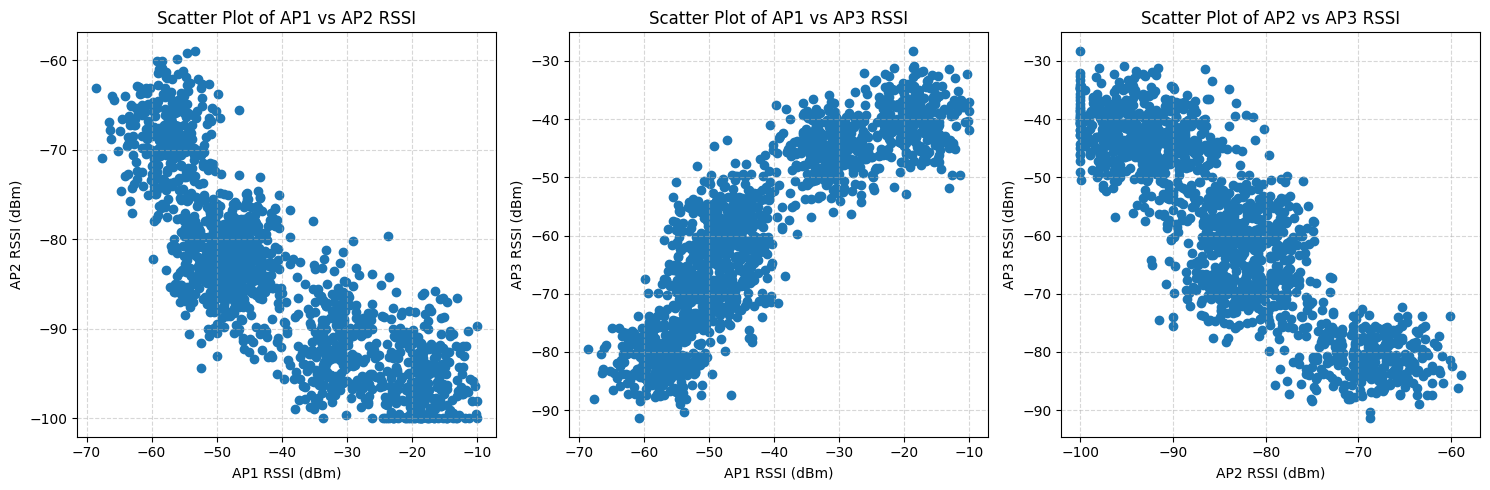

In [50]:
# grid of 3 plots
plt.figure(figsize=(15, 5))
plt.subplot(1, 3, 1)

# scatter plot of AP1 vs AP2
plt.scatter(rssi_df['AP1'], rssi_df['AP2'])
plt.xlabel('AP1 RSSI (dBm)')
plt.ylabel('AP2 RSSI (dBm)')
plt.title('Scatter Plot of AP1 vs AP2 RSSI')
plt.grid(True, linestyle='--', alpha=0.5)

# scatter plot of AP1 vs AP3
plt.subplot(1, 3, 2)
plt.scatter(rssi_df['AP1'], rssi_df['AP3'])
plt.xlabel('AP1 RSSI (dBm)')
plt.ylabel('AP3 RSSI (dBm)')
plt.title('Scatter Plot of AP1 vs AP3 RSSI')
plt.grid(True, linestyle='--', alpha=0.5)

# scatter plot of AP2 vs AP3
plt.subplot(1, 3, 3)
plt.scatter(rssi_df['AP2'], rssi_df['AP3'])
plt.xlabel('AP2 RSSI (dBm)')
plt.ylabel('AP3 RSSI (dBm)')
plt.title('Scatter Plot of AP2 vs AP3 RSSI')
plt.grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()


These plots suggest that data is grouped around certain clusters (approximately 4 or 5 clusters), which may correspond to different locations. Let us visualize the data in 3D.

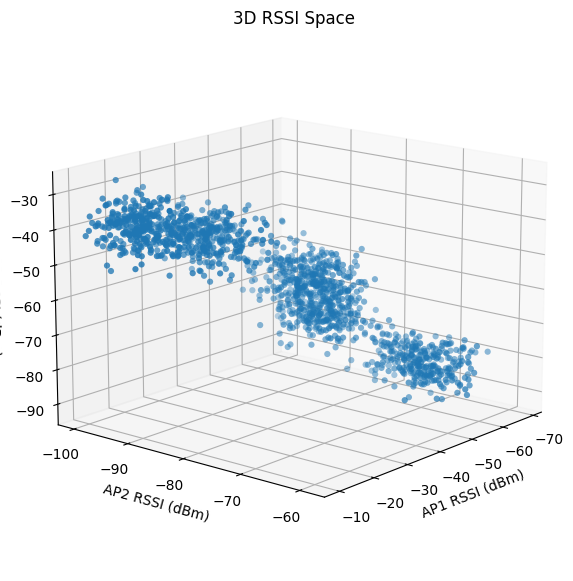

In [51]:
# Create the 3D scatter plot
fig = plt.figure(figsize=(11, 7))
ax = fig.add_subplot(111, projection="3d")

scatter = ax.scatter(
    rssi_df["AP1"],
    rssi_df["AP2"],
    rssi_df["AP3"],
    edgecolors="none",
)
ax.view_init(elev=15, azim=40)  # Adjust the elevation and azimuth for a better view

ax.set_title("3D RSSI Space")
ax.set_xlabel("AP1 RSSI (dBm)")
ax.set_ylabel("AP2 RSSI (dBm)")
ax.set_zlabel("AP3 RSSI (dBm)")

plt.show()

The 3D scatter plot reaffirms the presence of clusters in the data. Now, we will calculate the average RSSI and standard deviation for each of the 5 locations.

In [52]:
# concat dataframes
data_df = pd.concat([rssi_df, labels_df], axis=1)

# build dataframe with average and standard deviation of each location
summary_data = []

# group by location and calculate average and standard deviation for each AP
grouped = data_df.groupby('Location')
for location, group in grouped:
    ap1_avg = group['AP1'].mean()
    ap1_std = group['AP1'].std()
    ap2_avg = group['AP2'].mean()
    ap2_std = group['AP2'].std()
    ap3_avg = group['AP3'].mean()
    ap3_std = group['AP3'].std()
    avg = group[['AP1', 'AP2', 'AP3']].values.mean()
    std = group[['AP1', 'AP2', 'AP3']].values.std()
    
    summary_data.append({
        'Location': location,
        'AP1_Avg': ap1_avg,
        'AP1_Std': ap1_std,
        'AP2_Avg': ap2_avg,
        'AP2_Std': ap2_std,
        'AP3_Avg': ap3_avg,
        'AP3_Std': ap3_std,
        'Avg': avg,
        'Std': std
    })

summary_df = pd.DataFrame(summary_data)
summary_df

,Location,AP1_Avg,AP1_Std,AP2_Avg,AP2_Std,AP3_Avg,AP3_Std,Avg,Std
0,1,-57.547793,3.676167,-68.772187,4.041594,-81.156930,3.748209,-69.158970,10.370977
1,2,-49.811667,3.892066,-81.979633,3.760133,-68.978473,3.869161,-66.923258,13.757841
2,3,-46.740827,3.951756,-82.877667,3.981708,-57.633320,4.141495,-62.417271,15.660195
3,4,-31.584760,4.058027,-91.492630,3.944587,-45.475647,4.102736,-56.184346,25.917740
4,5,-18.477953,3.860880,-95.344790,3.531129,-40.081403,4.128701,-51.301382,32.595299


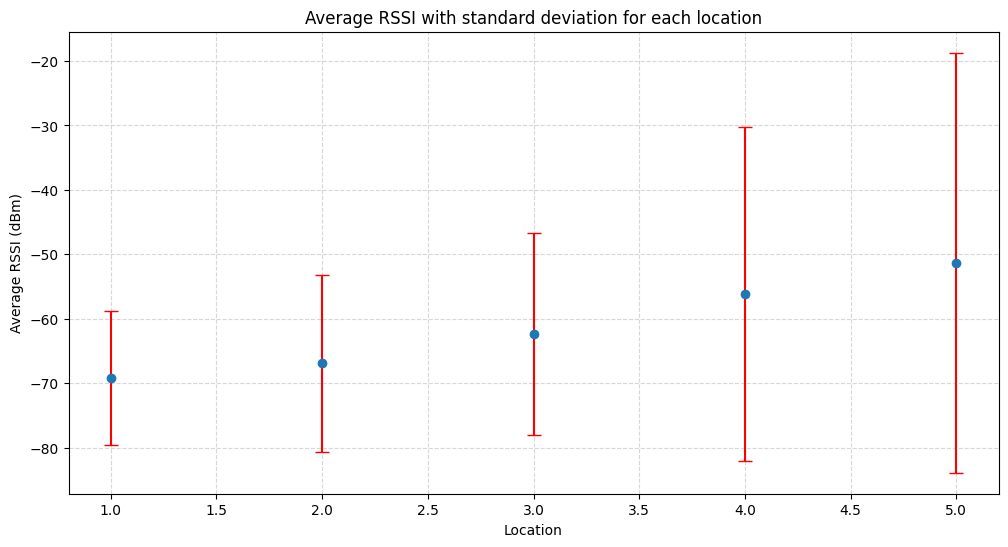

In [53]:
# plot average and standard deviation for each location
plt.figure(figsize=(12, 6))
plt.errorbar(summary_df['Location'], summary_df['Avg'], yerr=summary_df['Std'], fmt='o', ecolor='r', capsize=5)
plt.title('Average RSSI with standard deviation for each location')
plt.xlabel('Location')
plt.ylabel('Average RSSI (dBm)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

The above boxplot shows that the average RSSI value increases from location 1 to location 5, as well as the standard deviation.

## 2. K-means implementation

The K-means algorithm follows these steps:
1. Initialize k centroids by picking random points from the dataset
2. Assign each data point to the nearest centroid, forming k clusters
3. Update the centroids by calculating the mean of the data points in each cluster
4. Repeat steps 2 and 3 until convergence

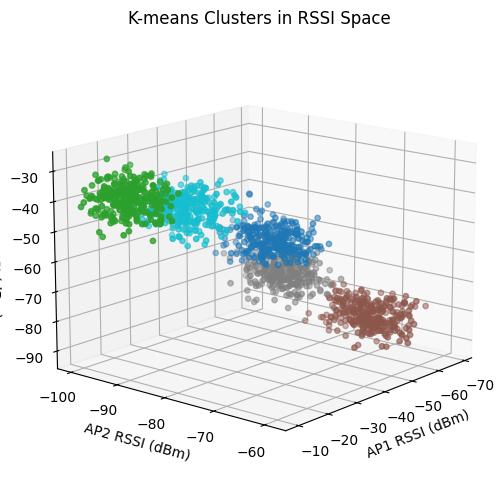

In [ ]:
X = rssi_df[['AP1', 'AP2', 'AP3']].values # convert to array
k = 5 # locations
max_iters = 100

# Initialize k centroids by picking random points from the dataset
rng = np.random.default_rng(42)
centroids = X[rng.choice(len(X), size=k, replace=False)] # select k random points

for _ in range(max_iters):
    # initialize labels as zeros
    labels = np.zeros(len(X), dtype=int)
    # Assign each point to the closest centroid
    for i in range(len(X)):
        # Compute euclidean distances to centroids
        distances = np.linalg.norm(X[i] - centroids, axis=1) # euclidean across rows
        # Assign label based on closest centroid
        labels[i] = np.argmin(distances)
    # Update centroids as the mean of assigned points
    for i in range(k):
        centroids[i] = X[labels == i].mean(axis=0) # average of each column

# visualize clusters in 3D
fig = plt.figure(figsize=(10, 6))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1], X[:, 2], c=labels, cmap='tab10', s=15)
ax.set_title('K-means Clusters in RSSI Space')
ax.set_xlabel('AP1 RSSI (dBm)')
ax.set_ylabel('AP2 RSSI (dBm)')
ax.set_zlabel('AP3 RSSI (dBm)')
ax.view_init(elev=15, azim=40)  # adjust the elevation and azimuth for a better view

plt.show()

### Evaluation

First we compare the raw predicted clusters with the ground truth locations.

In [55]:
eval_df = data_df.copy()
# add 1 to labels to match location numbering
eval_df['Predicted_Cluster'] = labels + 1
print(eval_df[['Location', 'Predicted_Cluster']].head(10))

   Location  Predicted_Cluster
0         5                  2
1         4                  5
2         5                  2
3         2                  4
4         2                  4
5         2                  4
6         2                  4
7         1                  3
8         4                  5
9         2                  4


We see that the predicted clusters do not map directly to the actual locations, so we apply a manual mapping to align the predicted clusters with the true locations.

In [56]:
# prediction to location mapping
mapping = {
    1: 3,
    2: 5,
    3: 1,
    4: 2,
    5: 4
}

# apply mapping to predicted clusters
eval_df['Predicted_Location'] = eval_df['Predicted_Cluster'].map(mapping)
# remove predicted_cluster column
eval_df.drop(columns=['Predicted_Cluster'], inplace=True)
print(eval_df[['Location', 'Predicted_Location']].head(10))


   Location  Predicted_Location
0         5                   5
1         4                   4
2         5                   5
3         2                   2
4         2                   2
5         2                   2
6         2                   2
7         1                   1
8         4                   4
9         2                   2


Now, we generate a confusion matrix to evaluate the performance of our clustering.

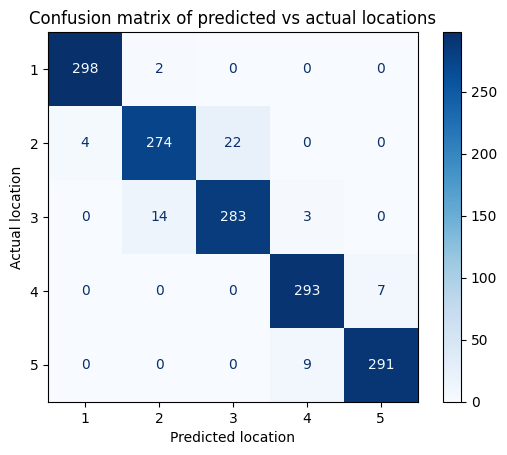

In [ ]:
cm = confusion_matrix(eval_df['Location'], eval_df['Predicted_Location'])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[1, 2, 3, 4, 5])
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion matrix of predicted vs actual locations')
plt.xlabel('Predicted location')
plt.ylabel('Actual location')
plt.show()

As we can see above, most of the samples are correctly classified, with location 1 having the highest accuracy and location 2 having the lowest. Let's also visualize the 3D scatter plot of the predictions vs. the true locations.

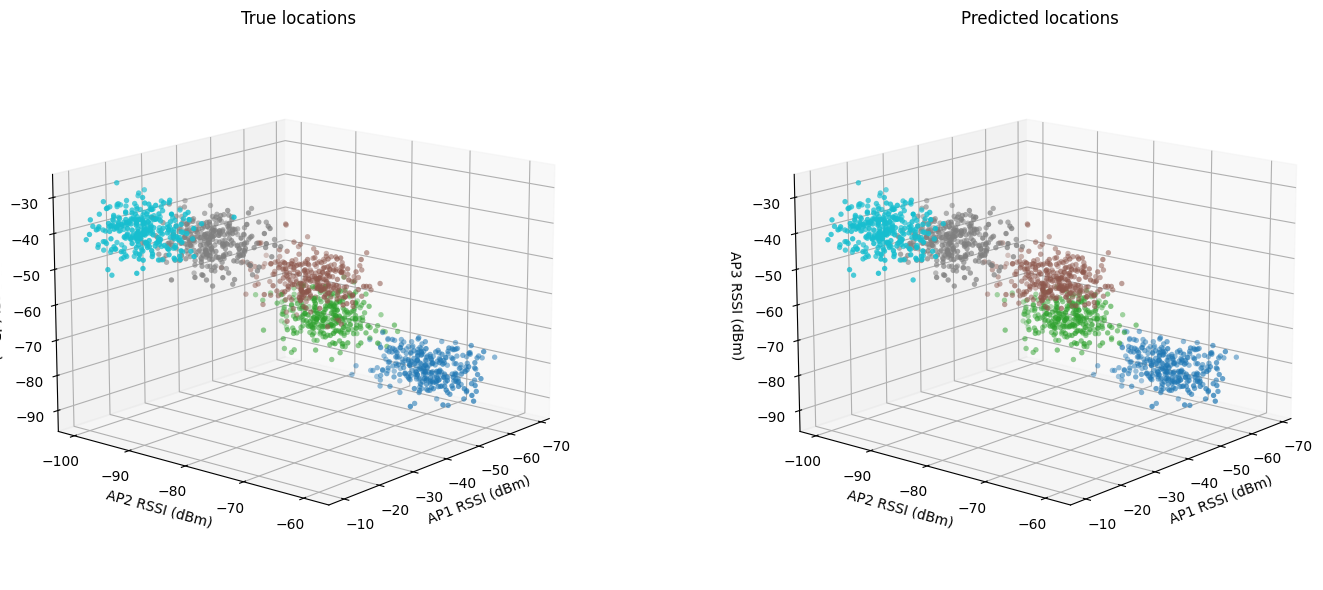

In [ ]:
# figure with two 3D subplots side by side
fig = plt.figure(figsize=(16, 6))

# Scatter plot of true locations
ax1 = fig.add_subplot(121, projection="3d")
ax1.scatter(
    eval_df["AP1"],
    eval_df["AP2"],
    eval_df["AP3"],
    c=eval_df["Location"],
    cmap='tab10',
    edgecolors="none",
    s=15,
)
ax1.view_init(elev=15, azim=40)
ax1.set_title("True locations", fontsize=12)
ax1.set_xlabel("AP1 RSSI (dBm)")
ax1.set_ylabel("AP2 RSSI (dBm)")
ax1.set_zlabel("AP3 RSSI (dBm)")

# Scatter plot of predicted locations
ax2 = fig.add_subplot(122, projection="3d")
ax2.scatter(
    eval_df["AP1"],
    eval_df["AP2"],
    eval_df["AP3"],
    c=eval_df["Predicted_Location"],
    cmap='tab10',
    edgecolors="none",
    s=15,
)
ax2.view_init(elev=15, azim=40)
ax2.set_title("Predicted locations", fontsize=12)
ax2.set_xlabel("AP1 RSSI (dBm)")
ax2.set_ylabel("AP2 RSSI (dBm)")
ax2.set_zlabel("AP3 RSSI (dBm)")

plt.tight_layout()
plt.show()

Finally, we calculate the overall accuracy of our clustering results.

In [59]:
# Calculate the overall accuracy
accuracy = accuracy_score(eval_df['Location'], eval_df['Predicted_Location'])

# Print the result as a percentage
print(f"Overall accuracy: {accuracy * 100:.2f}%")

Overall accuracy: 95.93%
